# Black-Oil Table — QC & Extension Demonstrator

This notebook walks through quality-controlling, filling, and extending a
Black-Oil Table with **`botkit`**. The numerical method is Singh & Whitson,
SPE 109596 (2007): the table is recast as a two-pseudocomponent K-value system,
the K-values are extended up to the convergence pressure and down to standard
conditions, and a two-component Peng-Robinson EOS (with Péneloux volume shifts
and Lohrenz-Bray-Clark viscosity) regenerates the properties.

The original notebook drove every decision by eye and with `input()` prompts.
Here the decisions are automated detectors that **flag** problems for a single
review, and every fix is recorded with its reason.

In [1]:
%matplotlib inline
import matplotlib as mpl
mpl.rcParams["figure.dpi"]=68  # keep the rendered notebook small for GitHub/nbviewer
import os, sys

# resolve the repository root whether this runs from repo root or notebooks/
ROOT = os.path.dirname(os.getcwd()) if os.path.basename(os.getcwd()) == "notebooks" else os.getcwd()
sys.path.insert(0, ROOT)
DATA = os.path.join(ROOT, "data", "PVTO&PVTG_example.xlsx")

from botkit import SurfaceFluids, read_excel, run_qc
from botkit.model import Config
from botkit import pipeline
from botkit.report import (diagnostics_to_markdown, changes_to_markdown,
                           plot_table)

## 1. Load the table and define the surface fluids

The example workbook holds saturated PVTO `(Rs, Pb, Bo, μo)` and PVTG
`(P, Rv, Bg, μg)` rows. The stock-tank oil and gas densities set the
two-pseudocomponent mixing constants.

In [2]:
surface = SurfaceFluids(st_oil_density=49.87, st_gas_density=0.0689)  # lbm/ft3
table = read_excel(DATA, surface=surface)
print(f"PVTO rows: {table.pvto.n}   PVTG rows: {table.pvtg.n}")
print(f"oil MW (correlated): {surface.oil_mw:.1f}   gas MW: {surface.gas_mw:.2f}")

PVTO rows: 32   PVTG rows: 32
oil MW (correlated): 138.7   gas MW: 26.15


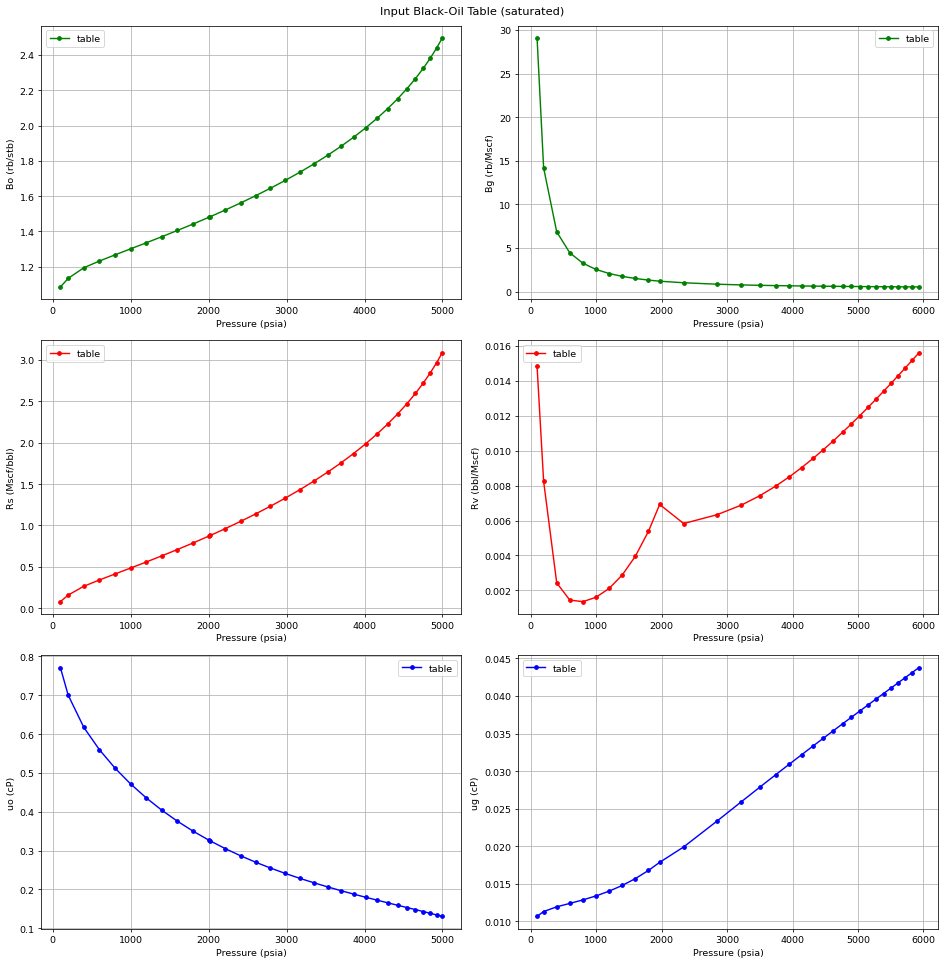

In [3]:
# the raw table, as loaded
fig = plot_table(table)
fig.suptitle("Input Black-Oil Table (saturated)", y=1.01);

## 2. Automated quality control

The detectors scan the table and return a severity-ranked report. On this fluid
they find two real defects that the original notebook handled by hand:

* the PVTO and PVTG saturated pressures **diverge above 1800 psia** — a prior
  non-equilibrium extension — so everything above the last shared pressure is
  discarded;
* a **low-pressure CGR (Rv) reversal** that most commercial simulators reject.

In [4]:
diag, suggestions = run_qc(table)
print(diagnostics_to_markdown(diag, suggestions))

# Black-Oil Table QC report

**0 error(s), 2 warning(s), 0 note(s).**

## Suggested configuration
- `saturated_cut` = 1800
- `cgr_floor` = 0.001354

## Anomalies
### [WARN] pressure_misalignment - P > 1800 psia
A discontinuity in the vaporized oil-gas ratio Rv above 1800 psia (a direction reversal that should not occur above the saturation pressure) marks a prior non-equilibrium extension. 22 oil and 22 gas rows lie above it.
*Suggested fix:* Discard saturated rows above 1800 psia (set Config.saturated_cut=1800).

### [WARN] cgr_reversal - P <= 800 psia
Saturated Rv reaches its minimum 0.001354 at 800 psia; 4 lower-pressure node(s) have higher Rv. This is a real retrograde feature but most commercial simulators require monotonic saturated Rv.
*Suggested fix:* Truncate saturated Rv below 800 psia to the minimum 0.001354 and drop their undersaturated rows (enforce_monotonic_cgr=True).



## 3. Build: trim → Pk → EOS tune → extend → fill

`pipeline.build` trims to the trusted locus, computes the convergence pressure
analytically (Singh App. B, on the trimmed data only), tunes the EOS and LBC
viscosity, extends the saturated tables **up** to `Pk` and **down** to `psc`, and
fills the undersaturated branches. `Pk` is left at its default (`AUTO`) so it is
the natural Singh fit, not a guess.

In [5]:
cfg = Config()
cfg.auto_apply_fixes = True   # proceed past QC; default Pk = Singh App. B
result = pipeline.build(table, cfg)

print(f"convergence pressure Pk : {result.info['Pk']:.0f} psia  (Singh App. B)")
print(f"trusted cut             : {result.info['cut']:.0f} psia")
print(f"saturated nodes (out)   : {result.info['n_saturated']}")
print(f"EOS upper-locus error   : {result.info['eos_pressure_error']:.1e}")
print(f"EOS trusted             : {result.info['eos_trusted']}")

convergence pressure Pk : 8195 psia  (Singh App. B)
trusted cut             : 1800 psia
saturated nodes (out)   : 28
EOS upper-locus error   : 4.9e-08
EOS trusted             : True


## 4. Change summary: what was done and why

Every corrective action is recorded with its justification. This same summary is
written into the Eclipse deck header so the rationale travels with the deck.

In [6]:
print(changes_to_markdown(result.changes))

# Black-Oil Table change summary

5 change(s) were applied:

1. **Discarded 22 PVTO and 22 PVTG saturated row(s) above 1800 psia, keeping a 10-node trusted locus.**
   _Why:_ A discontinuity in the vaporized oil-gas ratio Rv above this pressure (a direction reversal that should not occur above the saturation pressure) marks a prior non-equilibrium extension; only the trusted locus below it is retained.

2. **Stopped the extension at ~6824 psia (dropped the nodes above it).**
   _Why:_ Above this pressure the gas FVF Bg reversed direction, which is non-physical approaching the critical point; the K-value extrapolation cannot represent the sharp near-critical curvature there.

3. **Extended the saturated tables to a convergence pressure Pk = 8194.67 psia (11 extension node(s)).**
   _Why:_ Convergence pressure taken from the Singh App. B analytical estimate; with the K-values extended to K=1 at Pk, saturated properties above the table are regenerated from the tuned PR79 + Peneloux EOS an

## 5. The extended table

The solid markers are the (trusted) input nodes, passed through unchanged; the
dashed lines are the regenerated extensions. **Above** the table the K-values are
extended to `K = 1` at `Pk` and the properties are regenerated from the EOS,
stopping where a near-critical fold is detected. **Below** the lowest measured
node the locus is continued down to `psc` (14.696 psia): `Rs`/`Rv` from the
K-value origin poles via the binary VLE bijection (`Rs → 0` at `psc`), `Bo`
anchored to 1.0, `Bg` anchored at `psc`, and viscosities by mobility
continuation. Both extensions are defaults; `whitson_mode = True` reverts to the
classic constant-K extension with no low-side fill.

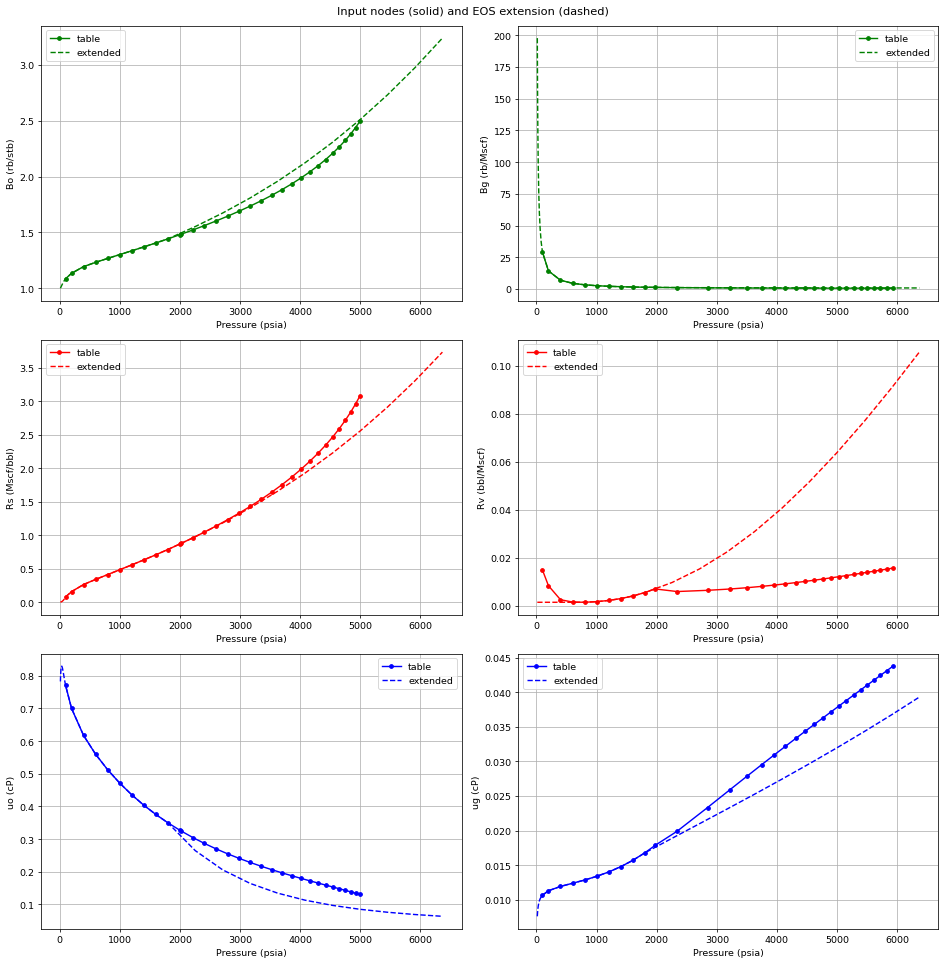

In [7]:
fig = plot_table(table, extended=result.extended)
fig.suptitle("Input nodes (solid) and EOS extension (dashed)", y=1.01);

## 6. Honour-the-data interpolation (composition-everywhere)

Between data points `botkit` interpolates with monotone PCHIP — not the EOS —
reproducing every input node exactly. The solution ratios are interpolated as
the gas mole fractions `x_g`, `y_g` (bounded and regular everywhere) and `Rs`,
`Rv` are formed from them at the query, avoiding the `K = y_g/x_g` singularity
at the `Rs = 0` edge.

max |Rs_interp - Rs_table| at nodes: 3.3306690738754696e-16


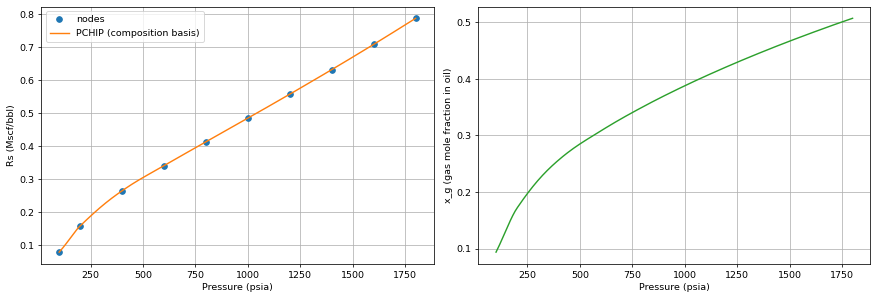

In [8]:
import numpy as np
interp = result.info["interpolator"]

# exact at the nodes
nodes = interp.evaluate(table.pvto.p[table.pvto.p <= 1800.001])
mask = table.pvto.p <= 1800.001
print("max |Rs_interp - Rs_table| at nodes:",
      float(np.max(np.abs(nodes["rs"] - table.pvto.rs[mask]))))

# smooth between the nodes
import matplotlib.pyplot as plt
grid = np.linspace(100, 1800, 300)
ev = interp.evaluate(grid)
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
ax[0].plot(table.pvto.p[mask], table.pvto.rs[mask], "o", label="nodes")
ax[0].plot(grid, ev["rs"], "-", label="PCHIP (composition basis)")
ax[0].set(xlabel="Pressure (psia)", ylabel="Rs (Mscf/bbl)"); ax[0].legend(); ax[0].grid(True)
ax[1].plot(grid, ev["xg"], "-", color="C2")
ax[1].set(xlabel="Pressure (psia)", ylabel="x_g (gas mole fraction in oil)"); ax[1].grid(True)
fig.tight_layout();

## 7. Viscosity: per-node VcVis and extrapolation conditioning

The LBC viscosity is f(rho / rho_pc), with rho the EOS phase density and rho_pc set
by the per-component VcVis. VcVis is regressed at each node to reproduce the
observed viscosities. The two ill-conditioned low-pressure nodes are dropped. The
plot shows the reliable VcVis is smooth only over ~400-1800 psia; extrapolating to
Pk is poorly constrained (oil VcVis is non-monotone, and trend vs flat diverge with
no data to arbitrate), so VcVis is held flat above the table by default.

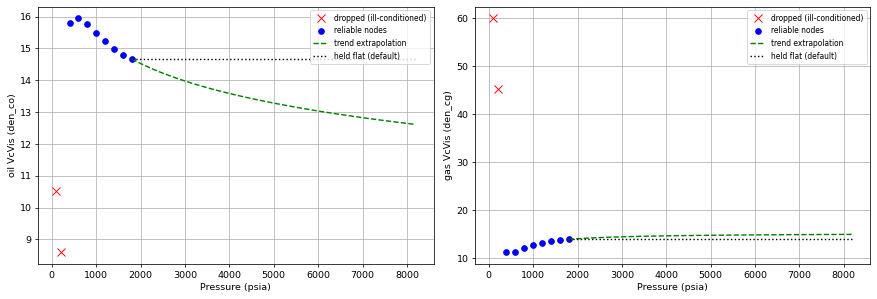

In [9]:
from botkit.viscosity import regress_node_densities
from botkit.eos import trend_extrapolator

fr = result.fit
dco, dcg, ok = regress_node_densities(fr.props, fr.lbc)
p = fr.props["p"]; pr = p[ok]; Pk = fr.Pk
pe = np.linspace(1800, Pk, 30)
fco, _ = trend_extrapolator(pr, dco[ok], 4, "log")
fcg, _ = trend_extrapolator(pr, dcg[ok], 4, "recip")

fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
for a, (d, fn, lab) in zip(ax, [(dco, fco, "oil VcVis (den_co)"),
                                (dcg, fcg, "gas VcVis (den_cg)")]):
    a.plot(p[~ok], d[~ok], "rx", ms=9, label="dropped (ill-conditioned)")
    a.plot(pr, d[ok], "bo", ms=6, label="reliable nodes")
    a.plot(pe, fn(pe), "g--", label="trend extrapolation")
    a.hlines(d[ok][-1], 1800, Pk, color="k", ls=":", label="held flat (default)")
    a.set(xlabel="Pressure (psia)", ylabel=lab); a.grid(True); a.legend(fontsize=8)
fig.tight_layout();

## 8. Write the Eclipse deck

`pipeline.write_deck` writes the PVTO/PVTG deck with the method and the change
summary embedded in the header.

In [10]:
deck = pipeline.write_deck(result, os.path.join(ROOT, "EXTENDED_PVT.inc"))
print("\n".join(deck.splitlines()[:16]))
print("...")

-- Black-Oil Table extended to convergence pressure
-- Method: Singh & Whitson, SPE 109596 (2007)
-- Pk = 8194.67 psia; trusted cut = 1800 psia
-- 
-- Change summary (5 applied):
-- 1. Discarded 22 PVTO and 22 PVTG saturated row(s) above 1800 psia, keeping a 10-node trusted locus.
--    Why: A discontinuity in the vaporized oil-gas ratio Rv above this pressure (a direction reversal that should not occur above the saturation pressure) marks a prior non-equilibrium extension; only the trusted locus below it is retained.
-- 2. Stopped the extension at ~6824 psia (dropped the nodes above it).
--    Why: Above this pressure the gas FVF Bg reversed direction, which is non-physical approaching the critical point; the K-value extrapolation cannot represent the sharp near-critical curvature there.
-- 3. Extended the saturated tables to a convergence pressure Pk = 8194.67 psia (11 extension node(s)).
--    Why: Convergence pressure taken from the Singh App. B analytical estimate; with the K-valu

## 9. Options and variations

A few of the knobs (see the README for the full list):

* `convergence_pressure_Pk` — override the analytical `Pk` (e.g. to extend less
  aggressively toward the critical point);
* `kvalue_extension` — `"convergence"` (default) extends K to `K = 1` at `Pk`;
  `"constant"` freezes K (classic constant-K extension);
* `extend_to_psc` / `reservoir_temperature` — continue the locus down to `psc`
  (default `True`); supplying a reservoir temperature anchors `Bg` at `psc` to a
  `Z = 1` ideal value instead of the frozen-Z pressure ratio;
* `whitson_mode = True` — revert everything to the classic conservative
  behaviour: constant-K high side, no low-side extension to `psc`;
* `shift_smoothness` — regularise the volume-shift trends for more confident
  extrapolation (`0` = exact per node);
* `enforce_monotonic_cgr = False` — keep the physically-real retrograde Rv
  reversal instead of the simulator-compliant truncation;
* `oil_shift_abscissa` / `gas_shift_abscissa` — the transform used to linearise
  each shift trend before extrapolation.

For example, overriding `Pk` to a lower value extends with no fold:

Pk = 5000 psia, nodes = 30, changes = 5


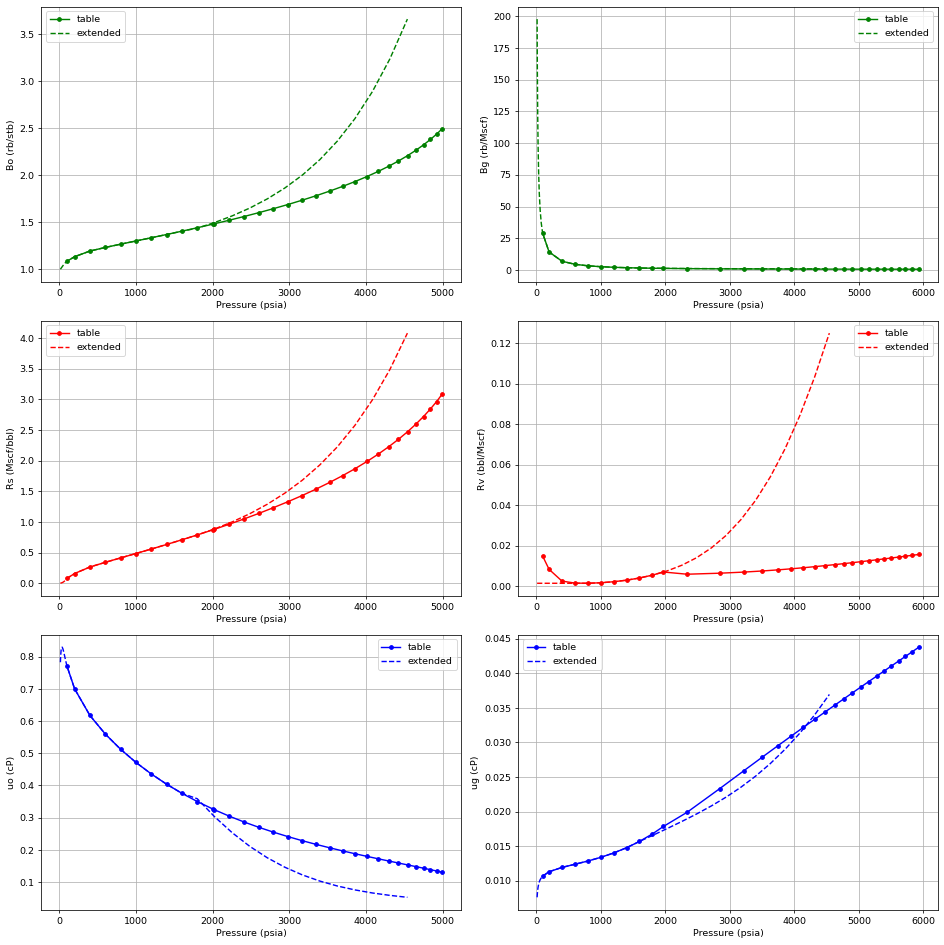

In [11]:
cfg2 = Config()
cfg2.auto_apply_fixes = True
cfg2.convergence_pressure_Pk = 5000.0   # user override (reported as such in the log)
cfg2.shift_smoothness = 1.0             # smooth, extrapolatable shift trends
res2 = pipeline.build(table, cfg2)
print(f"Pk = {res2.info['Pk']:.0f} psia, nodes = {res2.info['n_saturated']}, "
      f"changes = {len(res2.changes)}")
fig = plot_table(table, extended=res2.extended);